In [1]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from torch import nn, Tensor
import matplotlib.pyplot as plt
import numpy as np
from flow_matching.solver import ODESolver
from torch.utils.data import TensorDataset, DataLoader
import time
import torch.nn as nn
from sklearn.decomposition import PCA
import seaborn as sns

import sys
sys.path.append('./Textual-Anomaly-Detection-Framework/Anomaly Detection Framework')
from Modelisation.FlowMatching.flow_matching_transformers_token import FlowDiTToken, FlowMatchingTransformersToken
from Data_Preparation.utils import encode_tokens
import Modelisation.evaluation as ev
from utils import load_data_inlier, load_data_test, load_hyperparams
import Modelisation.evaluation as ev

2026-04-13 17:32:40.653071: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

%load_ext autoreload
%autoreload 2

Device: cuda


In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# télécharger si besoin
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))  # ou 'french'

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word.lower() not in stop_words]
    return " ".join(filtered)

def remove_stopwords_batch(batch):
    batch['text'] = [remove_stopwords(t) for t in batch['text']]
    return batch

[nltk_data] Downloading package punkt to
[nltk_data]     /home/2017025/ayouce01/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/2017025/ayouce01/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
dataset_name = '20newsgroups'
inlier_topic = 'science'
type_tac = None
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

# data_train = data_train.map(remove_stopwords_batch, batched=True)
# data_test = data_test.map(remove_stopwords_batch, batched=True)

print(data_train)
print(data_test)

X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2080
})
Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 1521
})


In [5]:
model_name = "roberta-base"
# model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

X_tokens_train, tokens_train, attentions_train, attentions_train_mask = encode_tokens(model, tokenizer, data_train['text'], device, batch_size=16, max_length=128)
X_tokens_test,  tokens_test,  attentions_test, attentions_test_mask  = encode_tokens(model, tokenizer, data_test['text'], device, batch_size=16, max_length=128)

print(X_tokens_train.shape) 
print(attentions_train.shape)   
print(tokens_train[10]) 
print(attentions_train_mask.shape)

# enlever les tokens <s> et </s> des attentions mask
mask = attentions_test_mask.clone()

mask[:, 0] = 0  

for i in range(mask.size(0)):
    last_idx = mask[i].nonzero()[-1].item()
    mask[i, last_idx] = 0

attentions_test_mask = mask

mask = attentions_train_mask.clone()

mask[:, 0] = 0  
for i in range(mask.size(0)):
    last_idx = mask[i].nonzero()[-1].item()
    mask[i, last_idx] = 0

attentions_train_mask = mask

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


torch.Size([2080, 128, 768])
torch.Size([2080, 128, 128])
['<s>', 'arch', 'iven', 'ame', 'Ġspac', 'en', 'ew', 'pro', 'bes', 'Ġlast', 'modified', 'Ġdate', 'Ġupcoming', 'Ġplanetary', 'Ġprobes', 'Ġmissions', 'Ġand', 'Ġschedules', 'Ġinformation', 'Ġon', 'Ġupcoming', 'Ġor', 'Ġcurrently', 'Ġactive', 'Ġmissions', 'Ġnot', 'Ġmentioned', 'Ġbelow', 'Ġwould', 'Ġbe', 'Ġwelcome', 'Ġsources', 'Ġn', 'asa', 'Ġfact', 'Ġsheets', 'Ġcass', 'ini', 'Ġmission', 'Ġdesign', 'Ġteam', 'Ġis', 'as', 'nas', 'da', 'Ġlaunch', 'Ġschedules', 'Ġpress', 'Ġkits', 'Ġas', 'uka', 'Ġast', 'rod', 'Ġis', 'as', 'Ġj', 'apan', 'Ġx', 'ray', 'Ġastronomy', 'Ġsatellite', 'Ġlaunched', 'Ġinto', 'Ġearth', 'Ġorbit', 'Ġon', 'Ġequipped', 'Ġwith', 'Ġlarge', 'area', 'Ġwid', 'ew', 'a', 'velength', 'Ġang', 'strom', 'Ġx', 'ray', 'Ġtelescope', 'Ġx', 'ray', 'Ġc', 'cd', 'Ġcameras', 'Ġand', 'Ġimaging', 'Ġgas', 'Ġsc', 'int', 'illation', 'Ġproportional', 'Ġcounters', 'Ġcass', 'ini', 'Ġsat', 'urn', 'Ġorbit', 'er', 'Ġand', 'Ġtitan', 'Ġatmosphere', 'Ġprob

In [6]:
nb_random_samples = 1000

config = {
        'latent_dim': 768,
        'hidden_dim': 256,
        'depth': 8,
        'n_heads': 8,
        'mlp_ratio': 4.0,
        'n_patches': 1,
        'freq_embed_size': 128,
        'lr': 1e-3,
        'weight_decay': 1e-3,
        'lambda_svdd': 1e-2,
        'lambda_push': 0,
        'lambda_margin': 0,
        'epochs': 500,
        'lr_epochs': 150,
        'warmup_epochs': -1,
        'grad_clip': 0.5,
        'flow_type': 'linear',
        'sigma': 0.1,
        'batch_size' : 256,
        'lambda_reg_angle': None,
        'lambda_reg_kl': None,
        'n_step_euler_integrate' : 1,
        'coef_var': 1,
        'rate_neg_batch':1.0,
        'sig_levels_neg' : [0.5, 0.7],
        'target' : 'gaussian-neigh',
        # 'source' : X_inlier.to(device)
        'source' : X_tokens_train.to(device)
        
}
noise_is_target = True
naming_dis = {
    'target' : config['target'] if noise_is_target else 'SBert',
    'source' : config['source'] if not noise_is_target else 'SBert'
}

flowmodel = FlowDiTToken(
            latent_dim=config['latent_dim'],
            hidden_dim=config['hidden_dim'],
            depth=config['depth'],
            n_heads=config['n_heads']
    ).to(device)

fm_transformer = FlowMatchingTransformersToken(flowmodel, config['source'], config['target'], config, noise_is_target=noise_is_target, rectified=None)

total_loss_liste, loss_fm_liste, loss_svdd_liste = fm_transformer.train(attentions_train_mask.to(device), True)


Epoch 1/500
Train Loss: 0.0101, LR: 0.000007
tensor(0.9999, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 167/500
Train Loss: 0.0032, LR: 0.000995
tensor(0.5618, device='cuda:0', grad_fn=<ExpBackward0>)

Epoch 333/500
Train Loss: 0.0012, LR: 0.000469
tensor(0.3445, device='cuda:0', grad_fn=<ExpBackward0>)


KeyboardInterrupt: 

In [7]:
name = f"nn_sms_128_{config['hidden_dim']}_ep{config['epochs']}"
saving_path = f'Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/fm_trained_models/{name}'
checkpoint = {
    "model": fm_transformer.model.state_dict(),
    "config": config
}
torch.save(checkpoint, saving_path)


# name = f"moy_computer_128_{config['hidden_dim']}_ep{config['epochs']}"
# model_saving_path = f'Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/fm_trained_models/{name}'

# checkpoint = torch.load(model_saving_path, map_location=device)
# config = checkpoint["config"]

# flowmodel = FlowDiTToken(
#     latent_dim=config['latent_dim'],
#     hidden_dim=config['hidden_dim'],
#     depth=config['depth'],
#     n_heads=config['n_heads']
# ).to(device)

# flowmodel.load_state_dict(checkpoint["model"])
# flowmodel.eval()

# fm_transformer = FlowMatchingTransformersToken(
#     flowmodel,
#     config['source'],
#     config['target'],
#     config,
#     noise_is_target=True,
#     rectified=None
# )

In [8]:
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'sum')
print()
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'mean')
print()
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'mediane')
print()
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'topk', k_rate=0.4)
print()
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'max')
print()
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'attention_weighted', None, attentions_test.to(device))
print()
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'weights', None, attentions_test.to(device))
print()
fm_attentions_test = fm_transformer.get_attention_maps(X_tokens_test, t_val=0.5).mean(dim=0)
_, _, _ = fm_transformer.test(X_tokens_test, attentions_test_mask.to(device), y_test, 'attention_weighted', None, fm_attentions_test)

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [124]:
# X = x_t_inter
# T, N, S, D = X.shape

# step_idx = np.linspace(0, T - 1, 8).astype(int)

# X_all = X.reshape(T * N * S, D)

# pca = PCA(n_components=2)
# pca.fit(X_all)

# fig, axes = plt.subplots(2, 4, figsize=(18, 8))
# axes = axes.flatten()

# for i, t in enumerate(step_idx):
#     Xt = X[t]  # (N, S, D)

#     Xt_flat = Xt.reshape(N * S, D)

#     Xt_2d = pca.transform(Xt_flat)

#     ax = axes[i]
#     ax.scatter(
#         Xt_2d[:, 0],
#         Xt_2d[:, 1],
#         s=1,
#         alpha=0.4
#     )

#     ax.set_title(f"t = {t} (normalized time ≈ {t/(T-1):.2f})")
#     ax.set_xticks([])
#     ax.set_yticks([])

# plt.tight_layout()
# plt.show()

In [8]:
def clean_tokens(batch_tokens):
    cleaned_batch = []

    for tokens in batch_tokens:
        cleaned = []
        for t in tokens:
            if t in ["<pad>", "<s>", "</s>"]:
                cleaned.append(None)  # garder alignement !
            else:
                cleaned.append(t.lstrip("Ġ"))
        cleaned_batch.append(cleaned)

    return cleaned_batch

def tokens_to_words_with_importance(tokens, importance):

    words = []
    word_importances = []

    current_word = ""
    current_scores = []

    for t, s in zip(tokens, importance):

        if t in ["<pad>", "<s>", "</s>"]:
            continue

        if t.startswith("Ġ"):
            if current_word != "":
                words.append(current_word)
                word_importances.append(np.mean(current_scores))

            current_word = t.lstrip("Ġ")
            current_scores = [s]

        else:
            current_word += t
            current_scores.append(s)

    if current_word != "":
        words.append(current_word)
        word_importances.append(np.mean(current_scores))

    return words, np.array(word_importances)


def plot_heatmap(importance, tokens, idx):
    scores = importance[idx].detach().cpu().numpy()
    # toks = clean_tokens(tokens)[idx]
    toks = tokens[idx]

    words, word_scores = tokens_to_words_with_importance(toks, scores)

    # masque basé sur tokens valides
    mask = [t is not None for t in words]

    # filtrage synchronisé
    words = [t for t, m in zip(words, mask) if m]
    word_scores = word_scores[mask]

    word_scores = word_scores.reshape(1, -1)

    plt.figure(figsize=(max(10, len(words) * 0.5), 2))

    sns.heatmap(
        word_scores,
        cmap="Reds",
        cbar=True,
        xticklabels=words,
        yticklabels=[]
    )

    plt.xticks(rotation=45, ha='right')
    plt.title(f"Token importance - Transport Gap")
    plt.tight_layout()
    plt.show()

In [9]:
x_final, velocities_token, x_t_inter = fm_transformer.euler_integrate(X_tokens_test.to(device), attentions_test_mask.to(device), 15, True)

print(x_t_inter.shape)
print(x_final.shape)
print(velocities_token.shape)

torch.Size([16, 966, 768])
torch.Size([966, 768])
torch.Size([15, 966, 128, 768])


In [10]:
# x_1_test = x_final.mean(dim=1).cpu().numpy()
x_1_test = x_final.cpu().numpy()
print(x_1_test.shape)
scores = np.sum((x_1_test - fm_transformer.centroid.repeat(x_1_test.shape[0],1).cpu().numpy()) ** 2, axis=1)
ev.evaluation(y_test, scores)

(966, 768)
AUC:        0.8061
Avg Precision: 0.2475
FPR@95:     0.4839


(0.8060823754789272, 0.4839080459770115, 0.24748030394652323)

### Velocity Norm

In [18]:
token_effort = velocities_token.norm(dim=-1).sum(dim=0)
token_effort = token_effort * attentions_test_mask

token_effort = token_effort / (
    token_effort.sum(dim=1, keepdim=True)
)

token_effort_inlier = token_effort[y_test == 0]
token_effort_anomaly = token_effort[y_test == 1]

tokens_test_inlier = np.array(tokens_test)[y_test == 0]
tokens_test_anomaly = np.array(tokens_test)[y_test == 1]

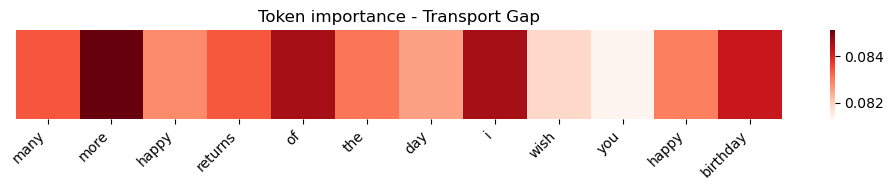

In [26]:
plot_heatmap(token_effort_inlier, tokens_test_inlier, idx=0)

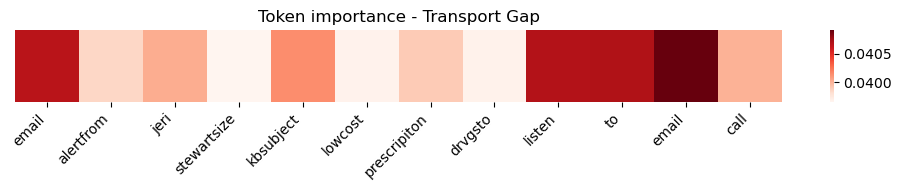

In [25]:
plot_heatmap(token_effort_anomaly, tokens_test_anomaly, idx=14)

### Distance to Centroid

In [17]:
dist_final = torch.norm(
    x_final.to(device) - fm_transformer.centroid.unsqueeze(0).unsqueeze(0), dim=-1
)
dist_final = dist_final * attentions_test_mask.to(device)

token_effort = dist_final / (
    dist_final.sum(dim=1, keepdim=True)
)

token_effort_inlier = token_effort[y_test == 0]
token_effort_anomaly = token_effort[y_test == 1]

tokens_test_inlier = np.array(tokens_test)[y_test == 0]
tokens_test_anomaly = np.array(tokens_test)[y_test == 1]

RuntimeError: The size of tensor a (966) must match the size of tensor b (128) at non-singleton dimension 1

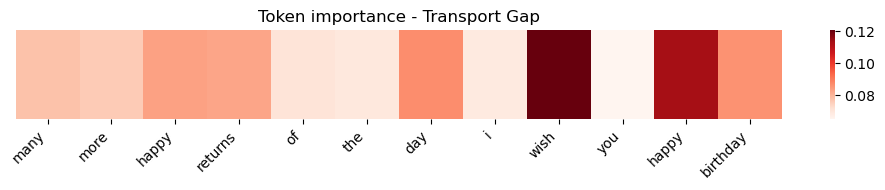

In [54]:
plot_heatmap(token_effort_inlier, tokens_test_inlier, idx=0)

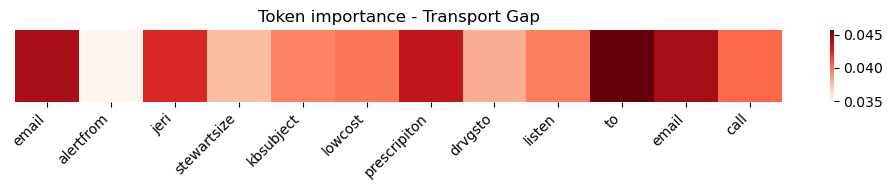

In [55]:
plot_heatmap(token_effort_anomaly, tokens_test_anomaly, idx=14)

### Velocity Variance

In [175]:
velocity_var = velocities_token.var(dim=0).mean(dim=-1)
velocity_var = velocity_var * attentions_test_mask

token_effort = velocity_var / (
    velocity_var.sum(dim=1, keepdim=True)
)

token_effort_inlier = token_effort[y_test == 0]
token_effort_anomaly = token_effort[y_test == 1]

tokens_test_inlier = np.array(tokens_test)[y_test == 0]
tokens_test_anomaly = np.array(tokens_test)[y_test == 1]


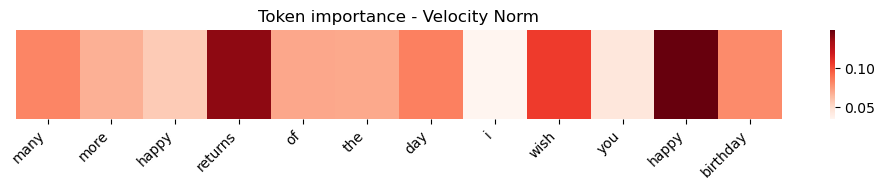

In [176]:
plot_heatmap(token_effort_inlier, tokens_test_inlier, idx=0)

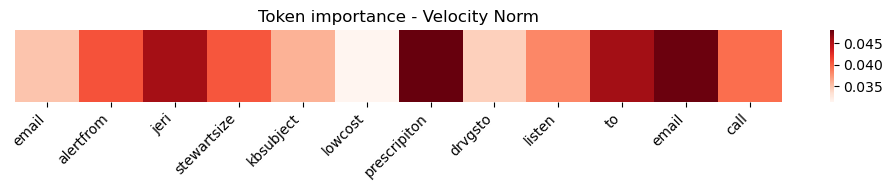

In [177]:
plot_heatmap(token_effort_anomaly, tokens_test_anomaly, idx=14)

### Distance au centroid entre t=0 et t=1
on calcule la difference de distance au centroid entre l'etat initial (t=0) et l'etat final (t=1). Une grande distance signifie un grand transport donc c'est probablement un token inlier car c'est deja vu lors de l'entrainement, tandis que quand la distance est petite c'est à dire le transport est presque nul donc c'est un token qui est hors distribution de celles vu pendant l'entrainement.

In [22]:
dist_over_time = torch.norm(
    x_t_inter.to(device) - fm_transformer.centroid.unsqueeze(0).unsqueeze(0).unsqueeze(0),
    dim=-1
)
converge_rate = torch.abs(dist_over_time[-1, :, :] - dist_over_time[0, :, :])

converge_rate = converge_rate * attentions_test_mask.to(device)

token_effort = converge_rate / (
    converge_rate.sum(dim=1, keepdim=True)
)

token_effort_inlier = token_effort[y_test == 0]
token_effort_anomaly = token_effort[y_test == 1]

tokens_test_inlier = np.array(tokens_test)[y_test == 0]
tokens_test_anomaly = np.array(tokens_test)[y_test == 1]


RuntimeError: The size of tensor a (1909) must match the size of tensor b (128) at non-singleton dimension 1

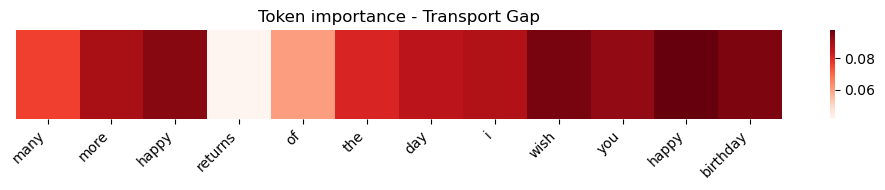

In [41]:
plot_heatmap(token_effort_inlier, tokens_test_inlier, idx=0)

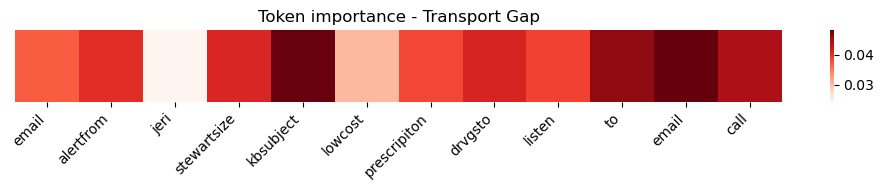

In [44]:
plot_heatmap(token_effort_anomaly, tokens_test_anomaly, idx=14)

In [15]:
idx = 17

fm_attentions_test = fm_transformer.get_attention_maps(X_tokens_test, t_val=0.5).mean(dim=0)
matrix = fm_attentions_test[idx].cpu().numpy()

mask = attentions_test_mask[idx].cpu().numpy().astype(bool)

valid_idx = np.where(mask)[0]

matrix_clean = matrix[np.ix_(valid_idx, valid_idx)]
tokens_clean = np.array([tokens_test[idx][i] for i in valid_idx]).reshape(-1,1)
print(tokens_clean)
tokens_clean = clean_tokens(tokens_clean)
print(tokens_clean)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix_clean,
    cmap="magma",
    xticklabels=tokens_clean,
    yticklabels=tokens_clean,
    square=True
)

plt.title(f"Sample {idx}")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

ValueError: too many values to unpack (expected 3)

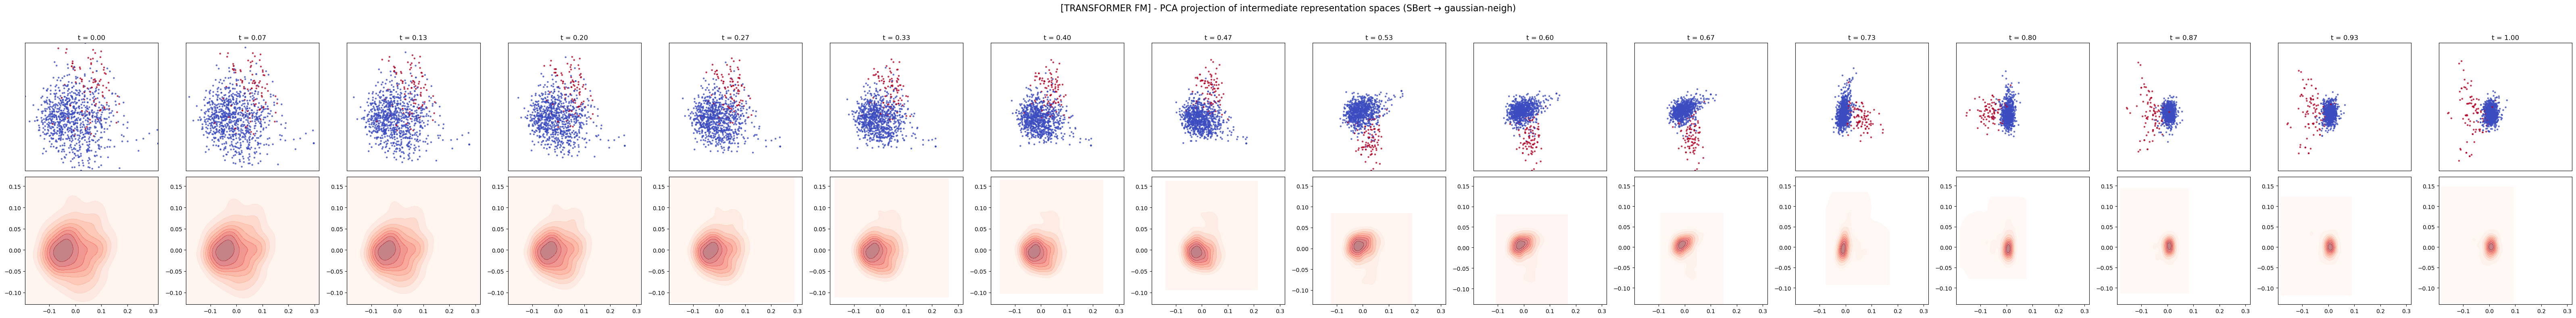

In [16]:
n_steps = 16
# X_np = x_t_inter.mean(dim=2).detach().cpu().numpy()
X_np = x_t_inter.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    X_2d_list = []
    for i in range(n_steps):
        if "t-SNE" in algos:
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            # X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])
        X_2d_list.append(X_2d)

        all_X = np.concatenate(X_2d_list, axis=0)
        x_min, x_max = all_X[:, 0].min(), all_X[:, 0].max()
        y_min, y_max = all_X[:, 1].min(), all_X[:, 1].max()

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=y_test,
            cmap="coolwarm",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)

        # ax_scatter.text(
        #     0.05, 0.95,
        #     f"AUC={metrics_history_norm[i][0]:.3f}\n"
        #     f"FPR95={metrics_history_norm[i][1]:.3f}\n"
        #     f"AP={metrics_history_norm[i][2]:.3f}",
        #     transform=ax_scatter.transAxes,
        #     fontsize=9,
        #     verticalalignment='top',
        #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        # )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

    fig.suptitle(
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [43]:
x_after, velocities_tokens = fm_transformer.euler_integrate(X_tokens_test.to(device), 15)
B, T, D = x_after.shape
scores = np.sum((x_after.cpu().numpy() - fm_transformer.centroid.unsqueeze(0).unsqueeze(0).repeat(B, T, 1).cpu().numpy()) ** 2, axis=2)
evaluation(y_test[:B], scores.mean(axis=1))
# fm_transformer.test(X_test[:10], y_test[:10], X_inlier, 'norm-centroid')

AUC:        0.5073
Avg Precision: 0.1152
FPR@95:     0.9216


(0.5072562127433349, 0.921612541993281, 0.11518525688446432)

In [40]:
name = f"science_256_{config['hidden_dim']}_ep{config['epochs']}"
saving_path = f'Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/fm_trained_models/{name}'
checkpoint = {
    "model": fm_transformer.model.state_dict(),
    "config": config
}
torch.save(checkpoint, saving_path)

In [11]:
name = f"science_256_{config['hidden_dim']}_ep{config['epochs']}"
model_saving_path = f'Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/fm_trained_models/{name}'

checkpoint = torch.load(model_saving_path, map_location=device)
config = checkpoint["config"]

flowmodel = FlowDiTToken(
    latent_dim=config['latent_dim'],
    hidden_dim=config['hidden_dim'],
    depth=config['depth'],
    n_heads=config['n_heads']
).to(device)

flowmodel.load_state_dict(checkpoint["model"])
flowmodel.eval()

fm_transformer = FlowMatchingTransformersToken(
    flowmodel,
    config['source'],
    config['target'],
    config,
    noise_is_target=True,
    rectified=None
)

/tmp/ipykernel_571899/3844898581.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_saving_path, map_location=device)


In [115]:
data = X_tokens_test[y_test==0][:10].to(device)
mask = attentions_test_mask[y_test == 0][:10]
# data = X_inlier[:10].to(device)
x_after, velocities_tokens, _ = fm_transformer.euler_integrate(data, mask.to(device), 15, True)

/tmp/ipykernel_581584/2528807041.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', G)


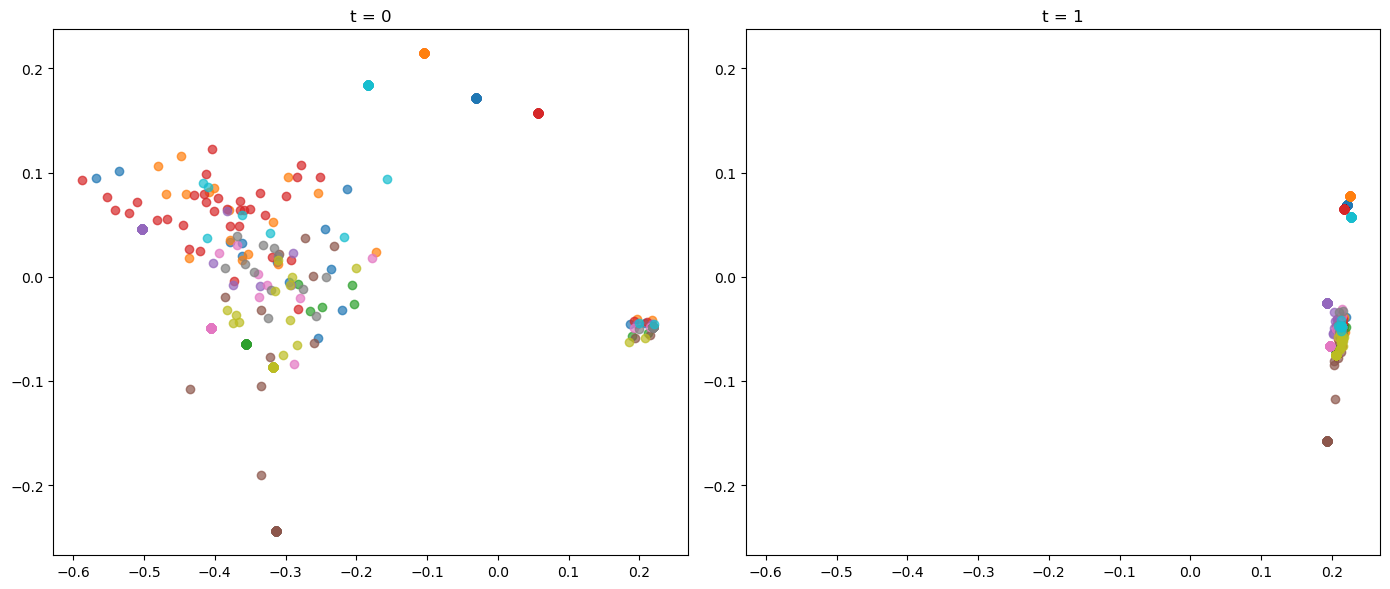

In [119]:
G, N, D = x_after.shape

x_all = torch.cat([
    x_after.to(device).view(-1, D),
    data.view(-1, D)
], dim=0).detach()

pca = PCA(n_components=2)
pca.fit(x_all.cpu().numpy())

def project(x):
    G, N, D = x.shape
    x_flat = x.view(-1, D).detach()
    x_pca = pca.transform(x_flat.cpu().numpy())
    return x_pca.reshape(G, N, 2)

x_after_pca = project(x_after)
x_inlier_pca = project(data)

cmap = plt.cm.get_cmap('tab10', G)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for i in range(G):
    axes[0].scatter(
        x_inlier_pca[i, :, 0],
        x_inlier_pca[i, :, 1],
        color=cmap(i),
        alpha=0.7
    )

axes[0].set_title("t = 0")
# axes[0].grid()

for i in range(G):
    axes[1].scatter(
        x_after_pca[i, :, 0],
        x_after_pca[i, :, 1],
        color=cmap(i),
        alpha=0.7
    )

axes[1].set_title("t = 1")
# axes[1].grid()

all_proj = np.concatenate([
    x_inlier_pca.reshape(-1, 2),
    x_after_pca.reshape(-1, 2)
], axis=0)

x_min, x_max = all_proj[:, 0].min(), all_proj[:, 0].max()
y_min, y_max = all_proj[:, 1].min(), all_proj[:, 1].max()

pad_x = 0.05 * (x_max - x_min)
pad_y = 0.05 * (y_max - y_min)

axes[0].set_xlim(x_min - pad_x, x_max + pad_x)
axes[0].set_ylim(y_min - pad_y, y_max + pad_y)

axes[1].set_xlim(x_min - pad_x, x_max + pad_x)
axes[1].set_ylim(y_min - pad_y, y_max + pad_y)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11755/3373869468.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(selected_idx))


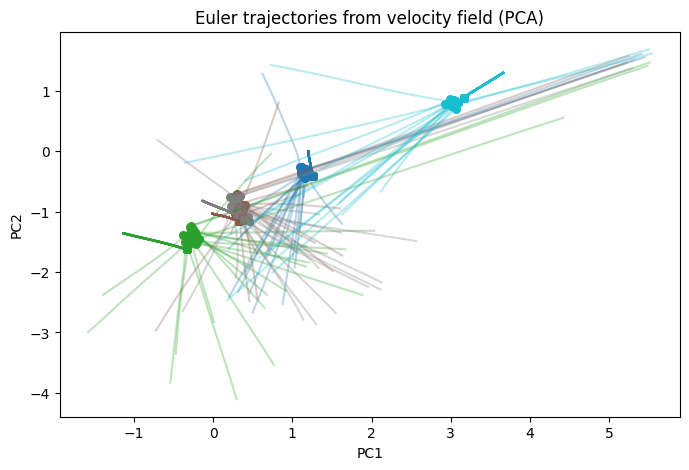

In [ ]:
velocities = velocities_tokens
T, G, N, D = velocities.shape

# condition initiale (t=0)
x0 = data.clone()  # (G, N, D)

# ===== PARAM =====
dt = 1.0 / T  # ou 1.0 si déjà discretisé comme ça
max_sentences = 5

selected_idx = np.random.choice(G, size=min(max_sentences, G), replace=False)

# ===== 1. Euler integration =====
x_traj = [x0]

x_t = x0.clone()
dt = 1.0 / T
for t in range(T):
    v_t = velocities[t]
    x_t = x_t + dt * v_t
    x_traj.append(x_t)

# (T+1, G, N, D)
x_traj = torch.stack(x_traj)

# ===== 2. PCA =====
x_flat = x_traj.reshape(-1, D).detach()
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_flat.cpu().numpy())

x_pca = x_pca.reshape(T+1, G, N, 2)

# ===== 3. Plot =====
plt.figure(figsize=(8,5))
cmap = plt.cm.get_cmap('tab10', len(selected_idx))

for i, g in enumerate(selected_idx):
    color = cmap(i)

    for n in range(N):
        traj = x_pca[:, g, n, :]  # (T+1, 2)

        # trajectoire
        plt.plot(
            traj[:, 0],
            traj[:, 1],
            color=color,
            alpha=0.3
        )

        # point initial
        # plt.scatter(
        #     traj[0, 0],
        #     traj[0, 1],
        #     color=color,
        #     marker='x',
        #     alpha=0.8
        # )

        # point final
        plt.scatter(
            traj[-1, 0],
            traj[-1, 1],
            color=color,
            s=30
        )

plt.title("Euler trajectories from velocity field (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.grid()
plt.show()

In [27]:
x_after_anom, velocities_tokens_anom = fm_transformer.euler_integrate(X_tokens_test[y_test==1].to(device), 15)
x_after_inli, velocities_tokens_inli = fm_transformer.euler_integrate(X_tokens_test[y_test==0].to(device), 15)

In [28]:
B, T, D = torch.concatenate([x_after_inli, x_after_anom]).shape
scores = np.sum((torch.concatenate([x_after_inli, x_after_anom]).cpu().numpy() - fm_transformer.centroid.unsqueeze(0).unsqueeze(0).repeat(B, T, 1).cpu().numpy()) ** 2, axis=2)
evaluation(torch.tensor([0]*x_after_inli.shape[0] + [1]*x_after_anom.shape[0]), scores.mean(axis=1))

AUC:        0.3379
Avg Precision: 0.0752
FPR@95:     0.8920


(0.3378711685823755, 0.8919540229885058, 0.07516280798927501)

In [30]:
def compactness_variance(X):
  ll = []
  for x in X:
    mu = x.mean(dim=0, keepdim=True)
    ll.append(((x - mu)**2).sum(dim=1).mean().item())
  return np.array(ll)

def compactness_pairwise(X):
    ll = []
    for x in X:
      dist = torch.cdist(x, x)
      ll.append(dist.mean().item())
    return np.array(ll)

print(compactness_variance(x_after_inli).mean())
print(compactness_variance(x_after_anom).mean())
_, _, _ = evaluation(y_test, compactness_variance(X_tokens_test))
print("-------------------------------------")

print(compactness_pairwise(x_after_inli).mean())
print(compactness_pairwise(x_after_anom).mean())
_, _, _ = evaluation(y_test, compactness_pairwise(X_tokens_test))
print("-------------------------------------")

0.0062781913112313755
0.011395233513515754
AUC:        0.7719
Avg Precision: 0.1898
FPR@95:     0.4908
-------------------------------------
0.05413829450891621
0.09274372768898805
AUC:        0.7948
Avg Precision: 0.2066
FPR@95:     0.4356
-------------------------------------


In [ ]:
import re

def get_tokens(tokenizer, data):
    return [
        # [re.sub(r"[ĠĊ]", "", t) for t in tokenizer.tokenize(dt['sms'])]
        [re.sub(r"[ĠĊ]", "", t) for t in tokenizer.tokenize(dt['text'])]
        for dt in data
    ]

def plot_heatmap(importance, tokens, idx):
    scores = importance[idx].detach().cpu().numpy().reshape(1, -1)
    toks = tokens[idx]

    plt.figure(figsize=(max(10, len(toks) * 0.5), 2))

    ax = sns.heatmap(
        scores,
        cmap="Reds",
        cbar=True,
        xticklabels=toks,
        yticklabels=[]
    )

    # rotation pour lisibilité
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Token importance - sample {idx}")

    plt.tight_layout()
    plt.show()

In [ ]:
token_importance_anom = torch.norm(velocities_tokens_anom[-1], dim=-1)
token_importance_anom = token_importance_anom / token_importance_anom.sum(dim=1, keepdim=True)
# test_data_anom = test_data.filter(lambda x: x['label'] == 1)
test_data_anom = test_outliers_sampled
tokens_anom = get_tokens(tokenizer, test_data_anom)

# plot_heatmap(token_importance_anom, tokens_anom, idx=0)

NameError: name 'velocities_tokens_anom' is not defined

In [ ]:
print(token_importance_anom.argmax(dim=1).shape)
print(tokens_anom[0])

torch.Size([191])
['What', 'is', 'your', 'proof', 'that', 'they', '"', 'did', 'the', 'best', 'they', 'could', '"?', 'Unless', 'they', 'had', 'strong', 'evidence', 'that', 'the', 'children', 'were', 'in', 'IM', 'MED', 'I', 'ATE', 'danger', 'then', '"', 'the', 'best', 'they', 'could', '"', 'have', 'done', 'was', 'to', 'SHOW', 'REST', 'RA', 'INT', '.', 'Some', 'of', 'us', 'DID', 'predict', 'this', 'outcome', ',', 'or', 'at', 'least', 'suggested', 'a', 'strong', 'possibility', 'of', 'it', '.', 'I', ',', 'for', 'one', ',', 'said', 'that', 'in', 'the', 'event', 'of', 'an', 'assault', 'against', 'the', 'building', 'the', 'CH', 'IL', 'DR', 'EN', 'were', 'the', 'ones', 'in', 'danger', 'either', 'from', 'the', 'assault', 'itself', 'or', 'from', 'a', '"', 'Jon', 'est', 'own', '"', '(', 'my', 'phrase', 'a', 'week', 'after', 'the', 'se', 'ige', 'started', ')', 'style', 'suicide', '.', 'And', 'as', 'I', 'pointed', 'out', 'then', ',', 'and', 'repeatedly', 'over', 'the', 'objections', 'of', 'people', 

In [ ]:
token_importance_inli = torch.norm(velocities_tokens_inli[-1], dim=-1)
token_importance_inli = token_importance_inli / token_importance_inli.sum(dim=1, keepdim=True)
# test_data_inli = test_data.filter(lambda x: x['label'] == 1)
test_data_inli = test_inliers
tokens_inli = get_tokens(tokenizer, test_data_inli)

# plot_heatmap(token_importance_inli, tokens_inli, idx=10)
print(token_importance_inli.argmax(dim=1))
print(tokens_inli[0][17])

tensor([17, 63, 17,  ..., 33, 32, 21], device='cuda:0')
ies


In [ ]:
print(token_importance_inli.argmin(dim=1))
print(tokens_inli[0][30])

tensor([30, 26,  6,  ..., 25, 42, 35], device='cuda:0')
've


In [ ]:
centroid_per_sample = x_after_anom.mean(dim=1)
dist_tokens = torch.norm(
    x_after_anom - centroid_per_sample.unsqueeze(1),
    dim=-1
)

contribution_anom = dist_tokens / dist_tokens.sum(dim=1, keepdim=True)

centroid_per_sample = x_after_inli.mean(dim=1)
dist_tokens = torch.norm(
    x_after_inli - centroid_per_sample.unsqueeze(1),
    dim=-1
)

contribution_inli = dist_tokens / dist_tokens.sum(dim=1, keepdim=True)

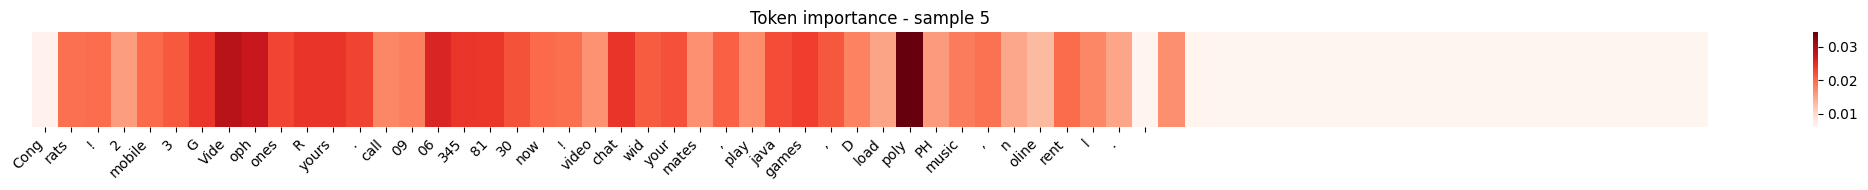

In [ ]:
plot_heatmap(contribution_anom, tokens_anom, idx=5)

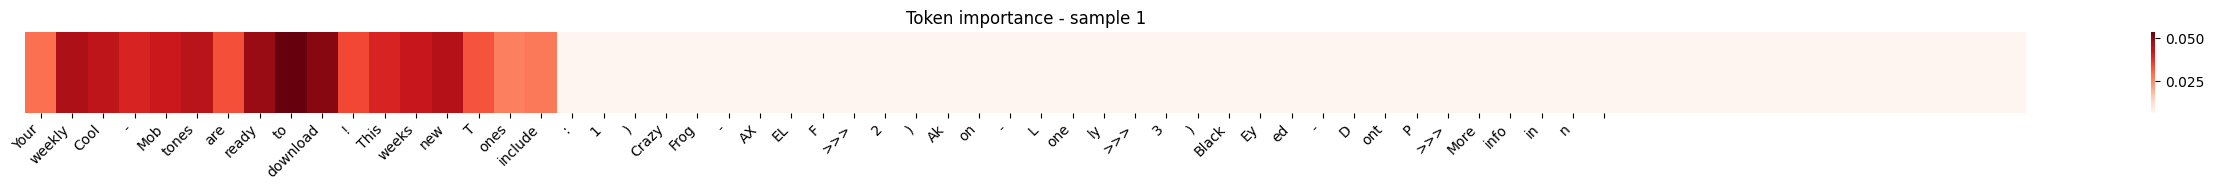

In [ ]:
plot_heatmap(contribution_inli, tokens_inli, idx=1)

In [ ]:
def plot_attention_maps(all_attentions, tokens_text, sample_idx=0):
    """
    all_attentions : (n_blocks, B, T, T)
    tokens_text    : liste de strings
    sample_idx     : quel sample visualiser
    """
    n_blocks = all_attentions.shape[0]
    T        = len(tokens_text)

    fig, axes = plt.subplots(1, n_blocks, figsize=(8 * n_blocks, 5))
    if n_blocks == 1:
        axes = [axes]

    for block_idx, ax in enumerate(axes):

        # Attention map du bloc block_idx pour le sample sample_idx
        attn = all_attentions[block_idx, sample_idx, :T, :T].cpu().numpy()

        sns.heatmap(
            attn,
            xticklabels=tokens_text,
            yticklabels=tokens_text,
            cmap='Blues',
            ax=ax,
            vmin=0, vmax=1,
            annot=True if T <= 10 else False,
            fmt='.2f'
        )
        ax.set_title(f'Block {block_idx} — Attention Map')
        ax.set_xlabel('Key tokens')
        ax.set_ylabel('Query tokens')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('attention_maps.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
x_tokens = X_test[y_test==0][:10].to(device)
all_attentions = fm_transformer.get_attention_maps(x_tokens, t_val=0.5)

tokens_inli = get_tokens(tokenizer, test_data_inli)[:10]
plot_attention_maps(all_attentions, tokens_inli[3], sample_idx=3)

NameError: name 'test_data_inli' is not defined

## Data

In [ ]:
dataset_name = '20newsgroups'
inlier_topic = 'computer'
type_tac = None
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 6

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

model.eval()

@torch.no_grad()
def encode_tokens(texts, device, batch_size=16, max_length=128):
    all_embeddings = []
    all_tokens = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        outputs = model(**inputs)
        last_hidden_state = outputs.last_hidden_state  # (B, T, D)

        # 🔥 normalisation token-wise (important pour distances locales)
        emb = torch.nn.functional.normalize(last_hidden_state, p=2, dim=2)

        all_embeddings.append(emb.cpu())

        # récupérer les tokens
        tokens = [tokenizer.convert_ids_to_tokens(ids) for ids in inputs["input_ids"]]
        all_tokens.extend(tokens)

    return torch.cat(all_embeddings, dim=0).to(device), all_tokens

X_tokens_train, tokens_train = encode_tokens(data_train['text'], device)
X_tokens_test, tokens_test = encode_tokens(data_test['text'], device)
print(X_tokens_train.shape, X_tokens_test.shape)

## EBMs

In [ ]:
def trajectory_direction(fmt, X, N_steps=20, device=device):
    """
    Retourne la distance au centroid à chaque timestep
    et la direction (convergente ou divergente)
    """
    fmt.model.eval()
    with torch.no_grad():
        trajectory = [X.clone()]
        distances  = [torch.norm(X - fmt.centroid, dim=1)]  # (B,)

        dt = 1.0 / N_steps
        x_t = X.clone()

        for i in range(N_steps):
            t_val = i * dt
            t = torch.full((x_t.shape[0],), t_val, device=device)
            v = fmt.model(x_t, t)
            x_t = x_t + dt * v

            dist = torch.norm(x_t - fmt.centroid, dim=1)  # (B,)
            trajectory.append(x_t.clone())
            distances.append(dist)

        distances = torch.stack(distances)  # (N_steps+1, B)

        # Dérivée discrète : dist[t+1] - dist[t]
        delta_dist = distances[1:] - distances[:-1]  # (N_steps, B)

        # Direction globale : convergente ou divergente ?
        # On regarde si la distance finale < distance initiale
        global_direction = distances[-1] - distances[0]  # (B,)
        # négatif = convergente, positif = divergente

    return distances.cpu(), delta_dist.cpu(), global_direction.cpu()

In [ ]:
nb_random_samples = 1000

config = {
        'latent_dim': 768,
        'hidden_dim': 256,
        'depth': 4,
        'n_heads': 4,
        'mlp_ratio': 4.0,
        'n_patches': 1,
        'freq_embed_size': 128,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'lambda_svdd': 1e-3,
        'lambda_push': 1e-3,
        'lambda_margin': 1e-4,
        'epochs': 1000,
        'lr_epochs': 300,
        'warmup_epochs': -1,
        'grad_clip': 0.5,
        'flow_type': 'linear',
        'sigma': 0.1,
        'batch_size' : 256,
        'lambda_reg_angle': None,
        'lambda_reg_kl': None,
        'n_step_euler_integrate' : 1,
        'coef_var': 1,
        'rate_neg_batch':1.0,
        'sig_levels_neg' : [0.5, 0.7],
        'target' : 'gaussian-neigh',
        'source' : X_inlier.to(device)
}
noise_is_target = True
naming_dis = {
    'target' : config['target'] if noise_is_target else 'SBert',
    'source' : config['source'] if not noise_is_target else 'SBert'
}

In [ ]:
for _ in range(1):

    flowmodel = FlowDiT(
                latent_dim=config['latent_dim'],
                hidden_dim=config['hidden_dim'],
                depth=config['depth'],
                n_heads=config['n_heads']
        ).to(device)

    fm_transformer = FlowMatchingTransformers(flowmodel, config['source'], config['target'], config, noise_is_target=noise_is_target, rectified=None)
    total_loss_liste, loss_fm_liste, loss_svdd_liste, loss_push_liste, margin_value_liste, r_in_value_liste = fm_transformer.train(True)

    print(fm_transformer.test(X_test, y_test, X_inlier, 'norm-centroid'))
    # print(fm_transformer.test(X_tokens_test, y_test, X_tokens_train, 'norm-centroid'))
    # print(fm_transformer.test(X_tokens_test[:1500], y_test[:1500], X_tokens_train, 'norm-centroid'))

    epochs = np.arange(len(total_loss_liste))

    r_in = np.array(r_in_value_liste)
    margin = np.array(margin_value_liste)
    r_out = r_in + margin

    fig, axs = plt.subplots(1, 5, figsize=(20, 5))

    axs[0].plot(epochs, total_loss_liste, label="total_loss")
    axs[0].set_title("Total Loss")
    axs[0].legend()

    axs[1].plot(epochs, loss_fm_liste, label="loss_fm")
    axs[1].set_title("Loss FM")
    axs[1].legend()

    axs[2].plot(epochs, loss_svdd_liste, label="loss_svdd")
    axs[2].set_title("Loss SVDD")
    axs[2].legend()

    axs[3].plot(epochs, loss_push_liste, label="loss_push")
    axs[3].set_title("Losses Push")
    axs[3].legend()

    axs[4].plot(epochs, r_in, label="r_in")
    # axs[3].plot(epochs, margin, label="margin")
    axs[4].plot(epochs, r_out, label="r_out")
    axs[4].set_title("Radii Evolution")
    axs[4].legend()

    plt.tight_layout()
    plt.show()

    # --------------------------
    # Train Inliers
    # --------------------------
    dist_train_inlier = torch.sum(
        (fm_transformer.forward_flow(X_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_train_inlier_r_in = ((dist_train_inlier < fm_transformer.r_in).float().mean() * 100).item()
    rate_train_inlier_r_in_r_out = (((dist_train_inlier >= fm_transformer.r_in) & (dist_train_inlier < fm_transformer.r_out)).float().mean() * 100).item()
    rate_train_inlier_r_out = ((dist_train_inlier >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Train-inliers dans r_in : {rate_train_inlier_r_in:.1f}%")
    print(f"% Train-inliers entre r_in et r_out : {rate_train_inlier_r_in_r_out:.1f}%")
    print(f"% Train-inliers dans r_out : {rate_train_inlier_r_out:.1f}%")
    print("--------------------------")

    nb_samples_neg = 130

    sigma_levels = [
        # 0.3 * torch.sqrt(fm_transformer.var),
        # 0.5 * torch.sqrt(fm_transformer.var)
        config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
        config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
    ]
    x_0_negative = []

    for i,sig in enumerate(sigma_levels):

        eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
        x_0_negative.extend(fm_transformer.centroid + eps)

    x_0_negative = torch.stack(x_0_negative).to(device)

    # --------------------------
    # Train Pseudo-Anomalies
    # --------------------------
    dist_train_pseudo = torch.sum(
        (fm_transformer.forward_flow(x_0_negative, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_train_pseudo_r_in = ((dist_train_pseudo < fm_transformer.r_in).float().mean() * 100).item()
    rate_train_pseudo_r_in_r_out = (((dist_train_pseudo >= fm_transformer.r_in) & (dist_train_pseudo < fm_transformer.r_out)).float().mean() * 100).item()
    rate_train_pseudo_r_out = ((dist_train_pseudo >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Train-PseudoAnom dans r_in : {rate_train_pseudo_r_in:.1f}%")
    print(f"% Train-PseudoAnom entre r_in et r_out : {rate_train_pseudo_r_in_r_out:.1f}%")
    print(f"% Train-PseudoAnom dans r_out : {rate_train_pseudo_r_out:.1f}%")
    print("--------------------------")

    # --------------------------
    # Test Inliers
    # --------------------------
    X_test_inlier = X_test[y_test == 0]

    dist_test_inlier = torch.sum(
        (fm_transformer.forward_flow(X_test_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_test_inlier_r_in = ((dist_test_inlier < fm_transformer.r_in).float().mean() * 100).item()
    rate_test_inlier_r_in_r_out = (((dist_test_inlier >= fm_transformer.r_in) & (dist_test_inlier < fm_transformer.r_out)).float().mean() * 100).item()
    rate_test_inlier_r_out = ((dist_test_inlier >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Test-inliers dans r_in : {rate_test_inlier_r_in:.1f}%")
    print(f"% Test-inliers entre r_in et r_out : {rate_test_inlier_r_in_r_out:.1f}%")
    print(f"% Test-inliers dans r_out : {rate_test_inlier_r_out:.1f}%")
    print("--------------------------")

    # --------------------------
    # Test Anomalies
    # --------------------------
    X_test_anom = X_test[y_test == 1]

    dist_test_anom = torch.sum(
        (fm_transformer.forward_flow(X_test_anom, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
        dim=1
    )

    rate_test_anom_r_in = ((dist_test_anom < fm_transformer.r_in).float().mean() * 100).item()
    rate_test_anom_r_in_r_out = (((dist_test_anom >= fm_transformer.r_in) & (dist_test_anom < fm_transformer.r_out)).float().mean() * 100).item()
    rate_test_anom_r_out = ((dist_test_anom >= fm_transformer.r_out).float().mean() * 100).item()

    print(f"% Test-anomalies dans r_in : {rate_test_anom_r_in:.1f}%")
    print(f"% Test-anomalies entre r_in et r_out : {rate_test_anom_r_in_r_out:.1f}%")
    print(f"% Test-anomalies dans r_out : {rate_test_anom_r_out:.1f}%")
    print("--------------------------")

    # --------------------------
    # Statistiques globales
    # --------------------------
    print(f"dist moyenne Train inliers     : {dist_train_inlier.mean():.4f}")
    print(f"dist moyenne Train pseudoAno   : {dist_train_pseudo.mean():.4f}")
    print(f"dist moyenne Test inliers      : {dist_test_inlier.mean():.4f}")
    print(f"dist moyenne Test anomalies    : {dist_test_anom.mean():.4f}")
    print(f"Gap Test : inliers/anomalies   : {dist_test_anom.mean() - dist_test_inlier.mean():.4f}")
    d_cohen = (dist_test_anom.mean() - dist_test_inlier.mean()) / (
        torch.sqrt((dist_test_inlier.var() + dist_test_anom.var()) / 2)
    )
    print(f"Cohen's d : {d_cohen:.4f}")
    print(f"r_in                            : {fm_transformer.r_in.item():.4f}")
    print(f"r_out                           : {fm_transformer.r_out.item():.4f}")
    print()
    distances, delta_dist, global_direction = trajectory_direction(fm_transformer, X_test, N_steps=50, device=device)
    print(f" Test Nb INLIER Examples diverge from centroid {(global_direction[y_test == 0][global_direction[y_test == 0] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb INLIER Examples converge to centroid {(global_direction[y_test == 0][global_direction[y_test == 0] < 0].shape[0] / X_test.shape[0])*100}%")

    print(f" Test Nb ANOMALIES Examples diverge from centroid {(global_direction[y_test == 1][global_direction[y_test == 1] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb ANOMALIES Examples converge to centroid {(global_direction[y_test == 1][global_direction[y_test == 1] < 0].shape[0] / X_test.shape[0])*100}%")
    print()
    distances, delta_dist, global_direction = trajectory_direction(fm_transformer, X_inlier, N_steps=50, device=device)
    print(f" Train Nb Examples diverge from centroid {(global_direction[global_direction > 0].shape[0] / X_inlier.shape[0])*100}%")
    print(f" Train Nb Examples converge to centroid {(global_direction[global_direction < 0].shape[0] / X_inlier.shape[0])*100}%")

In [ ]:
def visualize_trajectories(model, X_inlier, X_anomaly, n_samples=50, N_steps=20, device=device):
    model.eval()

    with torch.no_grad():
        # Collecte les trajectoires complètes
        def get_trajectory(x):
            trajectory = [x.clone()]
            dt = 1.0 / N_steps
            x_t = x.clone()
            for i in range(N_steps):
                t_val = i * dt
                t = torch.full((x_t.shape[0],), t_val, device=device)
                v = model(x_t, t)
                x_t = x_t + dt * v
                trajectory.append(x_t.clone())
            return torch.stack(trajectory)  # (N_steps+1, B, D)

        traj_in  = get_trajectory(X_inlier[:n_samples])   # (21, 50, 768)
        traj_out = get_trajectory(X_anomaly)  # (21, 50, 768)

    # PCA sur tous les points pour projection cohérente
    all_points = torch.cat([
        traj_in.reshape(-1, 768),
        traj_out.reshape(-1, 768)
    ], dim=0).cpu().numpy()

    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca.fit(all_points)

    # Projette les trajectoires
    traj_in_2d  = pca.transform(traj_in.reshape(-1, 768).cpu().numpy())
    traj_out_2d = pca.transform(traj_out.reshape(-1, 768).cpu().numpy())

    traj_in_2d  = traj_in_2d.reshape(N_steps+1, n_samples, 2)
    traj_out_2d = traj_out_2d.reshape(N_steps+1, X_anomaly.shape[0], 2)

    return traj_in, traj_out, traj_in_2d, traj_out_2d, pca

In [ ]:
traj_inliers = {}
traj_anomalies = {}
traj_inliers_all_dim = {}
traj_anomalies_all_dim = {}
pca_s = {}

n_samples = 200


traj_inliers_all_dim, traj_anomalies_all_dim, traj_inliers, traj_anomalies, pca_s = visualize_trajectories(fm_transformer.model, X_test[y_test==0], X_test[y_test==1], n_samples=n_samples, N_steps=20, device=device)

# nb_samples_neg = int(n_samples / 2)

# sigma_levels = [
#     # 0.3 * torch.sqrt(fm_transformer.var),
#     # 0.5 * torch.sqrt(fm_transformer.var)

#     config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
#     config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
# ]
# x_0_negative = []

# for i,sig in enumerate(sigma_levels):

#     eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
#     x_0_negative.extend(fm_transformer.centroid + eps)

# x_0_negative = torch.stack(x_0_negative).to(device)


# p = 0.10
# sigma = 0.85
# mask = torch.rand_like(X_inlier) < p  # p = proportion de dims perturbées
# noise = torch.randn_like(X_inlier) * sigma
# x_0_negative = X_inlier + mask * noise

# direction = torch.randn_like(X_inlier)
# direction = direction / direction.norm(dim=1, keepdim=True)
# alpha = 1.1
# x_0_negative = X_inlier + alpha * direction

# traj_inliers_all_dim, traj_anomalies_all_dim, traj_inliers, traj_anomalies, pca_s = visualize_trajectories(fm_transformer.model, X_inlier, x_0_negative, n_samples=n_samples, N_steps=20, device=device)

In [ ]:
title = ''

n_samples_ano = 96

traj_in_2d = traj_inliers
traj_out_2d = traj_anomalies

fig, ax = plt.subplots(figsize=(6, 6))

# Inliers
for i in range(n_samples):
    ax.plot(
        traj_in_2d[:, i, 0], traj_in_2d[:, i, 1],
        color='blue', alpha=0.2, linewidth=0.8
    )
    ax.scatter(
        traj_in_2d[-1, i, 0], traj_in_2d[-1, i, 1],
        color='navy', s=40, marker='.',
        label='Inlier' if i == 0 else None
    )

# Anomalies
for i in range(n_samples_ano):
    ax.scatter(
        traj_out_2d[-1, i, 0], traj_out_2d[-1, i, 1],
        color='darkred', s=40, marker='.',
        label='Anomaly' if i == 0 else None
    )
    ax.plot(
        traj_out_2d[:, i, 0], traj_out_2d[:, i, 1],
        color='red', alpha=0.2, linewidth=0.8
    )

# Centroid
centroid_2d = pca_s.transform(
    fm_transformer.centroid.cpu().numpy().reshape(1, -1)
)

ax.scatter(
    centroid_2d[0, 0], centroid_2d[0, 1],
    color='green', s=200, marker='+', linewidth=1,
    label='Centroid μ'
)

ax.set_title(title, fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
def trajectory_direction(fmt, X, N_steps=20, device=device):
    """
    Retourne la distance au centroid à chaque timestep
    et la direction (convergente ou divergente)
    """
    fmt.model.eval()
    with torch.no_grad():
        trajectory = [X.clone()]
        distances  = [torch.norm(X - fmt.centroid, dim=1)]  # (B,)

        dt = 1.0 / N_steps
        x_t = X.clone()

        for i in range(N_steps):
            t_val = i * dt
            t = torch.full((x_t.shape[0],), t_val, device=device)
            v = fmt.model(x_t, t)
            x_t = x_t + dt * v

            dist = torch.norm(x_t - fmt.centroid, dim=1)  # (B,)
            trajectory.append(x_t.clone())
            distances.append(dist)

        distances = torch.stack(distances)  # (N_steps+1, B)

        # Dérivée discrète : dist[t+1] - dist[t]
        delta_dist = distances[1:] - distances[:-1]  # (N_steps, B)

        # Direction globale : convergente ou divergente ?
        # On regarde si la distance finale < distance initiale
        global_direction = distances[-1] - distances[0]  # (B,)
        # négatif = convergente, positif = divergente

    return distances.cpu(), delta_dist.cpu(), global_direction.cpu()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# 1. Génération anomalies
# =========================
# direction = torch.randn_like(X_inlier)
# direction = direction / direction.norm(dim=1, keepdim=True)

# alpha = 3.1
# X_anomaly = X_inlier + alpha * direction

# nb_samples_neg = X_inlier.shape[0]

# sigma_levels = [
#     2.8 * torch.sqrt(fm_transformer.var),
#     2.9 * torch.sqrt(fm_transformer.var)

#     # config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
#     # config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
# ]
# x_0_negative = []

# for i,sig in enumerate(sigma_levels):

#     eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
#     x_0_negative.extend(fm_transformer.centroid + eps)

# X_anomaly = torch.stack(x_0_negative).to(device)

p = 0.10
sigma = 0.75
mask = torch.rand_like(X_inlier) < p  # p = proportion de dims perturbées
noise = torch.randn_like(X_inlier) * sigma
X_anomaly = X_inlier + mask * noise

# =========================
# 2. PCA fit sur inliers
# =========================
pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)

X_inlier_np = X_inlier.cpu().numpy()
X_anomaly_np = X_anomaly.cpu().numpy()

# Fit uniquement sur les inliers (important)
X_inlier_2d = pca_2d.fit_transform(X_inlier_np)
X_anomaly_2d = pca_2d.transform(X_anomaly_np)

X_inlier_3d = pca_3d.fit_transform(X_inlier_np)
X_anomaly_3d = pca_3d.transform(X_anomaly_np)

# =========================
# 3. Plot
# =========================
fig = plt.figure(figsize=(12, 5))
n_samples = 100

# ---- 2D ----
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_inlier_2d[:n_samples, 0], X_inlier_2d[:n_samples, 1], alpha=0.5, label="Inliers")
ax1.scatter(X_anomaly_2d[:n_samples, 0], X_anomaly_2d[:n_samples, 1], alpha=0.5, label="Anomalies")
ax1.set_title("PCA 2D")
ax1.legend()

# ---- 3D ----
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_inlier_3d[:n_samples, 0], X_inlier_3d[:n_samples, 1], X_inlier_3d[:n_samples, 2],
            alpha=0.5, label="Inliers")
ax2.scatter(X_anomaly_3d[:n_samples, 0], X_anomaly_3d[:n_samples, 1], X_anomaly_3d[:n_samples, 2],
            alpha=0.5, label="Anomalies")
ax2.set_title("PCA 3D")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
partitions = ['svdd1e-1','svdd1e-2', 'svdd1e-3', 'svdd1e-4']

dict_fmt_models = {}

for part in partitions:

    name = f"{dataset_name}_{inlier_topic}_{n_run}_{part}"
    model_saving_path = f"/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/fm_trained_models/{name}"

    checkpoint = torch.load(model_saving_path, map_location=device)
    config = checkpoint["config"]

    flowmodel = FlowDiT(
        latent_dim=config['latent_dim'],
        hidden_dim=config['hidden_dim'],
        depth=config['depth'],
        n_heads=config['n_heads']
    ).to(device)

    flowmodel.load_state_dict(checkpoint["model"])
    flowmodel.eval()

    dict_fmt_models[part] = FlowMatchingTransformers(
        flowmodel,
        config['source'],
        config['target'],
        config,
        noise_is_target=True,
        rectified=None
    )

In [ ]:
for part in partitions:
    print(dict_fmt_models[part].test(X_test, y_test, X_inlier, 'norm-centroid'))
    distances, delta_dist, global_direction = trajectory_direction(dict_fmt_models[part], X_test, N_steps=50, device=device)
    print(f" Test Nb INLIER Examples diverge from centroid {(global_direction[y_test == 0][global_direction[y_test == 0] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb INLIER Examples converge to centroid {(global_direction[y_test == 0][global_direction[y_test == 0] < 0].shape[0] / X_test.shape[0])*100}%")

    print(f" Test Nb ANOMALIES Examples diverge from centroid {(global_direction[y_test == 1][global_direction[y_test == 1] > 0].shape[0] / X_test.shape[0])*100}%")
    print(f" Test Nb ANOMALIES Examples converge to centroid {(global_direction[y_test == 1][global_direction[y_test == 1] < 0].shape[0] / X_test.shape[0])*100}%")
    print()
    print()

In [ ]:
traj_inliers = {}
traj_anomalies = {}
traj_inliers_all_dim = {}
traj_anomalies_all_dim = {}
pca_s = {}

n_samples = 200

for part in partitions:

    # traj_inliers_all_dim[part], traj_anomalies_all_dim[part], traj_inliers[part], traj_anomalies[part], pca_s[part] = visualize_trajectories(dict_fmt_models[part].model, X_test[y_test == 0], X_test[y_test == 1], n_samples=n_samples, N_steps=20, device=device)

    nb_samples_neg = int(n_samples / 2)

    sigma_levels = [
        # 0.3 * torch.sqrt(fm_transformer.var),
        # 0.5 * torch.sqrt(fm_transformer.var)

        config['sig_levels_neg'][0] * torch.sqrt(dict_fmt_models[part].var),
        config['sig_levels_neg'][1] * torch.sqrt(dict_fmt_models[part].var)
    ]
    x_0_negative = []

    for i,sig in enumerate(sigma_levels):

        eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
        x_0_negative.extend(dict_fmt_models[part].centroid + eps)

    x_0_negative = torch.stack(x_0_negative).to(device)
    traj_inliers_all_dim[part], traj_anomalies_all_dim[part], traj_inliers[part], traj_anomalies[part], pca_s[part] = visualize_trajectories(dict_fmt_models[part].model, X_inlier, x_0_negative, n_samples=n_samples, N_steps=20, device=device)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=False, sharey=False)
n_samples_ano = X_test[y_test == 1].shape[0]
# n_samples_ano = x_0_negative.shape[0]
# partitions = ['margin1e-1','margin1e-2', 'margin1e-3', 'margin1e-4']
mapp = {'Push 1e-1':partitions[0],
        'Push 1e-2':partitions[1],
        'Push 1e-3':partitions[2],
        'Push 1e-4':partitions[3]}

for ax, (traj_in_2d, traj_out_2d), title in zip(
    axes,
    [(traj_inliers[partitions[0]], traj_anomalies[partitions[0]]), (traj_inliers[partitions[1]], traj_anomalies[partitions[1]]),
      (traj_inliers[partitions[2]], traj_anomalies[partitions[2]]), (traj_inliers[partitions[3]], traj_anomalies[partitions[3]]) ],
    mapp.keys()

):
    # Trajectoires inliers
    for i in range(n_samples):
        ax.plot(
            traj_in_2d[:, i, 0], traj_in_2d[:, i, 1],
            color='blue', alpha=0.2, linewidth=0.8,
            # label='Trajectory' if i == 0 else None
        )
        # Point de départ
        # ax.scatter(traj_in_2d[0, i, 0],  traj_in_2d[0, i, 1],
        #           color='blue', s=20, zorder=5,marker='*',
        #           label='Start' if i == 0 else None)
        # Point d'arrivée
        ax.scatter(traj_in_2d[-1, i, 0], traj_in_2d[-1, i, 1],
                  color='navy', s=40, marker='.', zorder=5,
                  label='Inlier' if i == 0 else None)

    # Trajectoires anomalies
    for i in range(n_samples_ano):
        ax.plot(
            traj_out_2d[:, i, 0], traj_out_2d[:, i, 1],
            color='red', alpha=0.2, linewidth=0.8,
            #  label='Trajectory' if i == 0 else None
        )
        # ax.scatter(traj_out_2d[0, i, 0],  traj_out_2d[0, i, 1],
        #           color='red', s=20, zorder=5,marker='*',
        #           label='Start' if i == 0 else None)
        ax.scatter(traj_out_2d[-1, i, 0], traj_out_2d[-1, i, 1],
                  color='darkred', s=40, marker='.', zorder=5,
                  label='Anomaly' if i == 0 else None)

    # Centroid
    centroid_2d = pca_s[mapp[title]].transform(dict_fmt_models[mapp[title]].centroid.cpu().numpy().reshape(1, -1))
    ax.scatter(centroid_2d[0, 0], centroid_2d[0, 1],
              color='green', s=200, marker='+', linewidth=1,
              zorder=10, label='Centroid μ')

    # from matplotlib.patches import Circle

    # circle_r2 = Circle(
    # (centroid_2d[0, 0], centroid_2d[0, 1]),
    # radius=radius_s[title][0],
    # fill=False,
    # linestyle='--',
    # linewidth=1.5,
    # color='green'
    # )

    # circle_r4 = Circle(
    #     (centroid_2d[0, 0], centroid_2d[0, 1]),
    #     radius=radius_s[title][1],
    #     fill=False,
    #     linestyle='-',
    #     linewidth=1.5,
    #     color='red'
    # )

    # ax.add_patch(circle_r2)
    # ax.add_patch(circle_r4)

    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()

In [ ]:
def trajectory_direction(fmt, X, N_steps=20, device=device):
    """
    Retourne la distance au centroid à chaque timestep
    et la direction (convergente ou divergente)
    """
    fmt.model.eval()
    with torch.no_grad():
        trajectory = [X.clone()]
        distances  = [torch.norm(X - fmt.centroid, dim=1)]  # (B,)

        dt = 1.0 / N_steps
        x_t = X.clone()

        for i in range(N_steps):
            t_val = i * dt
            t = torch.full((x_t.shape[0],), t_val, device=device)
            v = fmt.model(x_t, t)
            x_t = x_t + dt * v

            dist = torch.norm(x_t - fmt.centroid, dim=1)  # (B,)
            trajectory.append(x_t.clone())
            distances.append(dist)

        distances = torch.stack(distances)  # (N_steps+1, B)

        # Dérivée discrète : dist[t+1] - dist[t]
        delta_dist = distances[1:] - distances[:-1]  # (N_steps, B)

        # Direction globale : convergente ou divergente ?
        # On regarde si la distance finale < distance initiale
        global_direction = distances[-1] - distances[0]  # (B,)
        # négatif = convergente, positif = divergente

    return distances.cpu(), delta_dist.cpu(), global_direction.cpu()

In [ ]:
distances, delta_dist, global_direction = trajectory_direction(dict_fmt_models['with_all'], X_test, N_steps=20, device=device)


In [ ]:
N_steps = 20
algo = 'onlyfm'

dist_in,  delta_in,  dir_in  = trajectory_direction(dict_fmt_models[algo], X_test[y_test == 0], N_steps=N_steps, device=device)
dist_out, delta_out, dir_out = trajectory_direction(dict_fmt_models[algo], X_test[y_test == 1], N_steps=N_steps, device=device)

t_axis = np.linspace(0, 1, N_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1 : distance au centroid au fil du temps ---
ax = axes[0]

# Moyenne + std sur tous les samples
mean_in  = dist_in.mean(dim=1).numpy()   # (N_steps+1,)
std_in   = dist_in.std(dim=1).numpy()
mean_out = dist_out.mean(dim=1).numpy()
std_out  = dist_out.std(dim=1).numpy()

ax.plot(t_axis, mean_in,  color='blue', linewidth=2, label='Inliers')
ax.fill_between(t_axis,
                mean_in - std_in,
                mean_in + std_in,
                alpha=0.2, color='blue')

ax.plot(t_axis, mean_out, color='red',  linewidth=2, label='Anomalies')
ax.fill_between(t_axis,
                mean_out - std_out,
                mean_out + std_out,
                alpha=0.2, color='red')

ax.axhline(0, color='green', linestyle='--', linewidth=1, label='Centroid μ')
ax.set_xlabel('t (flow time)', fontsize=12)
ax.set_ylabel('Distance to centroid μ', fontsize=12)
ax.set_title('Distance evolution along trajectory', fontsize=13)
ax.legend()

# --- Plot 2 : delta_dist (sens du mouvement) ---
ax = axes[1]

mean_delta_in  = delta_in.mean(dim=1).numpy()   # (N_steps,)
mean_delta_out = delta_out.mean(dim=1).numpy()
t_delta = np.linspace(0, 1, N_steps)

ax.plot(t_delta, mean_delta_in,  color='blue', linewidth=2, label='Inliers')
ax.plot(t_delta, mean_delta_out, color='red',  linewidth=2, label='Anomalies')
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Zone de convergence vs divergence
ax.fill_between(t_delta, mean_delta_in, 0,
                where=(mean_delta_in < 0),
                alpha=0.3, color='blue', label='Converging')
ax.fill_between(t_delta, mean_delta_out, 0,
                where=(mean_delta_out > 0),
                alpha=0.3, color='red', label='Diverging')

ax.set_xlabel('t (flow time)', fontsize=12)
ax.set_ylabel('Δ distance (convergent < 0, divergent > 0)', fontsize=12)
ax.set_title('Direction of transport', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('trajectory_directions.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
dir_out

In [ ]:
print(fm_transformer.r_in.item(), fm_transformer.margin.item(), fm_transformer.r_out.item())

In [ ]:
nb_samples_neg = 130

sigma_levels = [
    # 0.3 * torch.sqrt(fm_transformer.var),
    # 0.5 * torch.sqrt(fm_transformer.var)
    config['sig_levels_neg'][0] * torch.sqrt(fm_transformer.var),
    config['sig_levels_neg'][1] * torch.sqrt(fm_transformer.var)
]
x_0_negative = []

for i,sig in enumerate(sigma_levels):

    eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
    x_0_negative.extend(fm_transformer.centroid + eps)

x_0_negative = torch.stack(x_0_negative).to(device)

In [ ]:
# --------------------------
# Train Inliers
# --------------------------
dist_train_inlier = torch.sum(
    (fm_transformer.forward_flow(X_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_train_inlier_r_in = ((dist_train_inlier < fm_transformer.r_in).float().mean() * 100).item()
rate_train_inlier_r_in_r_out = (((dist_train_inlier >= fm_transformer.r_in) & (dist_train_inlier < fm_transformer.r_out)).float().mean() * 100).item()
rate_train_inlier_r_out = ((dist_train_inlier >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Train-inliers dans r_in : {rate_train_inlier_r_in:.1f}%")
print(f"% Train-inliers entre r_in et r_out : {rate_train_inlier_r_in_r_out:.1f}%")
print(f"% Train-inliers dans r_out : {rate_train_inlier_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Train Pseudo-Anomalies
# --------------------------
dist_train_pseudo = torch.sum(
    (fm_transformer.forward_flow(x_0_negative, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_train_pseudo_r_in = ((dist_train_pseudo < fm_transformer.r_in).float().mean() * 100).item()
rate_train_pseudo_r_in_r_out = (((dist_train_pseudo >= fm_transformer.r_in) & (dist_train_pseudo < fm_transformer.r_out)).float().mean() * 100).item()
rate_train_pseudo_r_out = ((dist_train_pseudo >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Train-PseudoAnom dans r_in : {rate_train_pseudo_r_in:.1f}%")
print(f"% Train-PseudoAnom entre r_in et r_out : {rate_train_pseudo_r_in_r_out:.1f}%")
print(f"% Train-PseudoAnom dans r_out : {rate_train_pseudo_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Test Inliers
# --------------------------
X_test_inlier = X_test[y_test == 0]

dist_test_inlier = torch.sum(
    (fm_transformer.forward_flow(X_test_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_test_inlier_r_in = ((dist_test_inlier < fm_transformer.r_in).float().mean() * 100).item()
rate_test_inlier_r_in_r_out = (((dist_test_inlier >= fm_transformer.r_in) & (dist_test_inlier < fm_transformer.r_out)).float().mean() * 100).item()
rate_test_inlier_r_out = ((dist_test_inlier >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Test-inliers dans r_in : {rate_test_inlier_r_in:.1f}%")
print(f"% Test-inliers entre r_in et r_out : {rate_test_inlier_r_in_r_out:.1f}%")
print(f"% Test-inliers dans r_out : {rate_test_inlier_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Test Anomalies
# --------------------------
X_test_anom = X_test[y_test == 1]

dist_test_anom = torch.sum(
    (fm_transformer.forward_flow(X_test_anom, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

rate_test_anom_r_in = ((dist_test_anom < fm_transformer.r_in).float().mean() * 100).item()
rate_test_anom_r_in_r_out = (((dist_test_anom >= fm_transformer.r_in) & (dist_test_anom < fm_transformer.r_out)).float().mean() * 100).item()
rate_test_anom_r_out = ((dist_test_anom >= fm_transformer.r_out).float().mean() * 100).item()

print(f"% Test-anomalies dans r_in : {rate_test_anom_r_in:.1f}%")
print(f"% Test-anomalies entre r_in et r_out : {rate_test_anom_r_in_r_out:.1f}%")
print(f"% Test-anomalies dans r_out : {rate_test_anom_r_out:.1f}%")
print("--------------------------")

# --------------------------
# Statistiques globales
# --------------------------
print(f"dist moyenne Train inliers     : {dist_train_inlier.mean():.4f}")
print(f"dist moyenne Train pseudoAno   : {dist_train_pseudo.mean():.4f}")
print(f"dist moyenne Test inliers      : {dist_test_inlier.mean():.4f}")
print(f"dist moyenne Test anomalies    : {dist_test_anom.mean():.4f}")
print(f"Gap Test : inliers/anomalies   : {dist_test_anom.mean() - dist_test_inlier.mean():.4f}")
d_cohen = (dist_test_anom.mean() - dist_test_inlier.mean()) / (
    torch.sqrt((dist_test_inlier.var() + dist_test_anom.var()) / 2)
)
print(f"Cohen's d : {d_cohen:.4f}")
print(f"r_in                            : {fm_transformer.r_in.item():.4f}")
print(f"r_out                           : {fm_transformer.r_out.item():.4f}")

In [ ]:
margin = np.array(margin_value_liste)
r_in = np.array(r_in_value_liste)
r_out = r_in + margin

epochs = np.linspace(1, len(r_in)-1, 10, dtype=int)

rmax = r_out.max()

fig, axes = plt.subplots(2, 5, figsize=(18,7))

for ax, e in zip(axes.flatten(), epochs):

    rin = r_in[e]
    rout = r_out[e]

    # surfaces
    area_total = np.pi * rmax**2
    area_in = np.pi * rin**2
    area_margin = np.pi * (rout**2 - rin**2)
    area_out = np.pi * (rmax**2 - rout**2)

    p_in = 100 * area_in / area_total
    p_margin = 100 * area_margin / area_total
    p_out = 100 * area_out / area_total

    # fond = région outliers
    ax.set_facecolor("#DBF7D0")

    # disque inliers
    circle_in = plt.Circle((0,0), rin, color="#195401", alpha=0.8)
    margin_cut = plt.Circle((0,0), rout, color="white")

    ax.add_patch(margin_cut)
    ax.add_patch(circle_in)

    # frontières
    ax.add_patch(plt.Circle((0,0), rin, fill=False, linewidth=2))
    ax.add_patch(plt.Circle((0,0), rout, fill=False, linestyle="--", linewidth=2))

    ax.set_xlim(-1.1*rmax, 1.1*rmax)
    ax.set_ylim(-1.1*rmax, 1.1*rmax)
    ax.set_aspect('equal')

    ax.set_title(f"Epoch {e}")

    # label en haut à droite
    label = (
        f"in: {p_in:.1f}%\n"
        f"margin: {p_margin:.1f}%\n"
        f"out: {p_out:.1f}%"
    )

    ax.text(
        0.97, 0.97,
        label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
labels = ["Train Inliers", "Train PseudoAno", "Test Inliers", "Test Anomalies"]

inside_rin = [rate_train_inlier_r_in, rate_train_pseudo_r_in, rate_test_inlier_r_in, rate_test_anom_r_in]
between = [rate_train_inlier_r_in_r_out, rate_train_pseudo_r_in_r_out, rate_test_inlier_r_in_r_out, rate_test_anom_r_in_r_out]
outside = [rate_train_inlier_r_out, rate_train_pseudo_r_out, rate_test_inlier_r_out, rate_test_anom_r_out]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))

plt.bar(x, inside_rin, label="inside r_in")
plt.bar(x, between, bottom=inside_rin, label="r_in → r_out")

bottom2 = np.array(inside_rin) + np.array(between)
plt.bar(x, outside, bottom=bottom2, label="> r_out")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Percentage")
plt.title("Distribution of samples across regions")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
labels = ["Train Inliers", "Train PseudoAno", "Test Inliers", "Test Anomalies"]
distances = [
    dist_train_inlier.mean().item(),
    dist_train_pseudo.mean().item(),
    dist_test_inlier.mean().item(),
    dist_test_anom.mean().item()
]

colors = ['skyblue', 'lightblue', 'salmon', 'lightcoral']

x = np.array([0, 1, 3, 4])
width = 0.8

plt.figure(figsize=(8,4))
plt.bar(x, distances, width=width, color=colors)

plt.axhline(fm_transformer.r_in.item(), linestyle="--", label="r_in", color='green')
plt.axhline(fm_transformer.r_out.item(), linestyle="--", label="r_out", color='red')

plt.xticks(x, labels)

plt.ylabel("Mean distance to centroid")
plt.title("Average distance to centroid")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

# TRAIN
ax[0].hist(dist_train_inlier.cpu().numpy(), bins=50, alpha=0.7, label="Train Inliers", density=True)
ax[0].hist(dist_train_pseudo.cpu().numpy(), bins=50, alpha=0.7, label="Pseudo Anomalies", density=True)

ax[0].axvline(fm_transformer.r_in.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_in", color='green')
ax[0].axvline(fm_transformer.r_out.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_out", color='red')

ax[0].set_title("Train distances")
ax[0].set_xlabel("Distance")
ax[0].set_ylabel("Density")
ax[0].legend()

# TEST
ax[1].hist(dist_test_inlier.cpu().numpy(), bins=50, alpha=0.7, label="Test Inliers", density=True)
ax[1].hist(dist_test_anom.cpu().numpy(), bins=50, alpha=0.7, label="Test Anomalies", density=True)

ax[1].axvline(fm_transformer.r_in.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_in", color='green')
ax[1].axvline(fm_transformer.r_out.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_out", color='red')

ax[1].set_title("Test distances")
ax[1].set_xlabel("Distance")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
dist_sq = torch.sum((fm_transformer.forward_flow(X_test,'midpoint',8)[-1] - fm_transformer.centroid)**2, dim=1)
r_sq = fm_transformer.r_in ** 2
sss = dist_sq - r_sq
ev.evaluation(y_test, sss.cpu().detach().numpy())

In [ ]:
nb_samples_neg = 130

sigma_levels = [
    0.3 * torch.sqrt(fm_transformer.var),
    0.5 * torch.sqrt(fm_transformer.var)
]
x_0_negative = []

for i,sig in enumerate(sigma_levels):

    eps = sig * torch.randn((i+1)*nb_samples_neg, 768).to(device)
    x_0_negative.extend(fm_transformer.centroid + eps)

x_0_negative = torch.stack(x_0_negative).to(device)


alpha = 1.15

direction = X_inlier - fm_transformer.centroid
x_0_negative = fm_transformer.centroid + alpha * direction


dist_train_inlier = torch.sum(
    (fm_transformer.forward_flow(X_inlier, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)
dist_train_pseudo = torch.sum(
    (fm_transformer.forward_flow(x_0_negative, 'midpoint', 8)[-1] - fm_transformer.centroid) ** 2,
    dim=1
)

fig, ax = plt.subplots(1,1, figsize=(12,4))

# TRAIN
plt.hist(dist_train_inlier.cpu().numpy(), bins=50, alpha=0.7, label="Train Inliers", density=True)
plt.hist(dist_train_pseudo.cpu().numpy(), bins=50, alpha=0.7, label="Pseudo Anomalies", density=True)

plt.axvline(fm_transformer.r_in.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_in", color='green')
plt.axvline(fm_transformer.r_out.cpu().detach().numpy(), linestyle="--", linewidth=2, label="r_out", color='red')

plt.title("Train distances")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
n_steps = 8
x_intermer_test_noise = fm_transformer.forward_flow(X_test,'midpoint',n_steps)
x_intermer_inlier_noise = fm_transformer.forward_flow(X_inlier,'midpoint',n_steps)
# x_intermer_test_noise = dict_fmt_models['onlyfm'].forward_flow(X_test,'midpoint',n_steps)
# x_intermer_inlier_noise = dict_fmt_models['onlyfm'].forward_flow(X_inlier,'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), torch.randn(100, X_inlier.shape[1]).to(device))),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), 0.2*torch.zeros(nb_random_samples, X_inlier.shape[1]).to(device) + (0.008 ** 0.5) * torch.randn((nb_random_samples, 768)).to(device))),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate((X_inlier.to(device), X_inlier.to(device) )),'midpoint',n_steps)
# x_intermer_inlier_noise = fm_transformer.forward_flow(torch.concatenate([X_inlier, X_anom_for_train]).to(device),'midpoint',n_steps)

metrics_history_maha = []
metrics_history_norm = []
metrics_history_norm_train = []

for num_repre_space in range(n_steps):

    ############## MANALANOBIS ####################

    x_1_inliers = x_intermer_inlier_noise[num_repre_space].cpu().numpy()

    mean_inlier = np.mean(x_1_inliers, axis=0)
    cov_inlier = np.cov(x_1_inliers.T)
    cov_inlier += 1e-6 * np.eye(cov_inlier.shape[0])

    diff = x_intermer_test_noise[num_repre_space].cpu().numpy() - mean_inlier
    inv_cov = np.linalg.inv(cov_inlier)

    scores = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))
    metrics_history_maha.append(ev.evaluation(y_test, scores, verbose=False))


    ################### NORM ########################

    # scores = np.sum(x_intermer_test_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    scores = np.sum((x_intermer_test_noise[num_repre_space].cpu().numpy() - fm_transformer.centroid.repeat(x_intermer_test_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    # scores = np.sum((x_intermer_test_noise[num_repre_space].cpu().numpy() - dict_fmt_models['onlyfm'].centroid.repeat(x_intermer_test_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    metrics_history_norm.append(ev.evaluation(y_test, scores, verbose=False))

    # # # ss = np.sum(x_intermer_inlier_noise[num_repre_space].cpu().numpy() ** 2, axis=1)
    # ss = np.sum((x_intermer_inlier_noise[num_repre_space].cpu().numpy() - fm_transformer.centroid.repeat(x_intermer_inlier_noise[num_repre_space].cpu().numpy().shape[0],1).cpu().numpy()) ** 2, axis=1)
    # metrics_history_norm_train.append(ev.evaluation(y_train, ss, verbose=False))

metrics_history_maha = np.array(metrics_history_maha)
metrics_history_norm = np.array(metrics_history_norm)
metrics_history_norm_train = np.array(metrics_history_norm_train)

In [ ]:
X_np = x_intermer_test_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    X_2d_list = []
    for i in range(n_steps):
        if "t-SNE" in algos:
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])
        X_2d_list.append(X_2d)

        all_X = np.concatenate(X_2d_list, axis=0)
        x_min, x_max = all_X[:, 0].min(), all_X[:, 0].max()
        y_min, y_max = all_X[:, 1].min(), all_X[:, 1].max()

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            c=y_test,
            cmap="coolwarm",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)

        ax_scatter.text(
            0.05, 0.95,
            f"AUC={metrics_history_norm[i][0]:.3f}\n"
            f"FPR95={metrics_history_norm[i][1]:.3f}\n"
            f"AP={metrics_history_norm[i][2]:.3f}",
            transform=ax_scatter.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

    fig.suptitle(
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
X_np = x_intermer_inlier_noise.detach().cpu().numpy()
algos = {
    # "t-SNE": TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42),
    "PCA": PCA(n_components=2),
    # "SVD": TruncatedSVD(n_components=2)
}

time_steps = torch.linspace(0.0, 1.0, n_steps)

for algo_name, algo in algos.items():
    fig, axes = plt.subplots(2, n_steps, figsize=(4 * n_steps, 8))
    if n_steps == 1:
        axes = axes.reshape(2, 1)

    X_2d_list = []
    for i in range(n_steps):
        if "t-SNE" in algos:
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, init="pca", random_state=42)
            X_2d = reducer.fit_transform(X_np[i])
        else:
            X_2d = algo.fit_transform(X_np[i])
        X_2d_list.append(X_2d)

        all_X = np.concatenate(X_2d_list, axis=0)
        x_min, x_max = all_X[:, 0].min(), all_X[:, 0].max()
        y_min, y_max = all_X[:, 1].min(), all_X[:, 1].max()

        ax_scatter = axes[0, i]
        ax_scatter.scatter(
            X_2d[:, 0],
            X_2d[:, 1],
            # c=y_train,
            # cmap="bwr",
            s=5,
            alpha=0.7
        )
        ax_scatter.set_title(f"t = {time_steps[i].item():.2f}")
        ax_scatter.set_xticks([])
        ax_scatter.set_yticks([])
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)

        # ax_scatter.text(
        #     0.05, 0.95,
        #     f"AUC={metrics_history_norm_train[i][0]:.3f}\n"
        #     f"FPR95={metrics_history_norm_train[i][1]:.3f}\n"
        #     f"AP={metrics_history_norm_train[i][2]:.3f}",
        #     transform=ax_scatter.transAxes,
        #     fontsize=9,
        #     verticalalignment='top',
        #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        # )
        ax_kde = axes[1, i]
        sns.kdeplot(
            x=X_2d[:, 0],
            y=X_2d[:, 1],
            ax=ax_kde,
            fill=True,
            cmap="Reds",
            alpha=0.5,
            levels=10,
            thresh=0
        )
        ax_kde.set_xlim(x_min, x_max)
        ax_kde.set_ylim(y_min, y_max)

    fig.suptitle(
        f"[TRANSFORMER FM] - {algo_name} projection of intermediate representation spaces ({naming_dis['source']} → {naming_dis['target']})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
def collect_temporal_metrics(model, x, time_steps):
    norms = []
    dvdt_vals = []

    for t in time_steps:
        t_batch = torch.ones(x.size(0), 1, device=x.device) * t
        t_batch.requires_grad_(True)

        v = model(x, t_batch)

        norm_v = v.norm(dim=1)
        norms.append(norm_v.detach())

        dvdt = torch.autograd.grad(
            norm_v.sum(),
            t_batch,
            retain_graph=True
        )[0]

        dvdt_vals.append(dvdt.detach())

    norms = torch.stack(norms, dim=1)
    dvdt_vals = torch.stack(dvdt_vals, dim=1)

    return norms, dvdt_vals

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
norms_inlier, dvdt_vals = collect_temporal_metrics(fm_transformer.model, X_inlier, time_steps)
norms_test, dvdt_vals = collect_temporal_metrics(fm_transformer.model, X_test, time_steps)

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, torch.mean(norms_inlier, dim=0).cpu().numpy(), label='Train', color='tab:blue', linewidth=2)
plt.plot(time_steps, torch.mean(norms_test[y_test == 1], dim=0).cpu().numpy(), label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, torch.mean(norms_test[y_test == 0], dim=0).cpu().numpy(), label='Test_Inliers', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields Gradient', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
plt.imshow(norms_test[y_test==1].cpu(), aspect='auto')
# plt.imshow(norms_inlier.cpu(), aspect='auto')
plt.colorbar()
plt.title("Velocity norm per sample over time")
plt.show()

In [ ]:
def grad_norm(model, x, t):
    x = x.requires_grad_(True)
    v = model(x, t)

    grad = torch.autograd.grad(
        v.norm(),
        x,
        retain_graph=False,
        create_graph=False
    )[0]

    return grad.norm(dim=1)

In [ ]:
dt = 1.0 / n_steps
l_norm_train = []

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_inlier.shape[0])
    l_norm_train.append(torch.mean(grad_norm(fm_transformer.model, X_inlier, t)).item())

l_norm_anom = []
l_norm_inlier = []

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_test[y_test==1].shape[0])
    l_norm_anom.append(torch.mean(grad_norm(fm_transformer.model, X_test[y_test==1], t)).item())

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(X_test[y_test==0].shape[0])
    l_norm_inlier.append(torch.mean(grad_norm(fm_transformer.model, X_test[y_test==0], t)).item())

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, l_norm_train, label='Test_Inliers', color='tab:blue', linewidth=2)
plt.plot(time_steps, l_norm_anom, label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, l_norm_inlier, label='Train', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields Gradient', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
x_bis = fm_transformer.sample_like(X_test, 'gaussian-neigh')

In [ ]:
x0 = X_test
x_t = x0.clone().to(device)
x_traj_test = [x_t.clone()]
v_fields_test = []

dt = 1.0 / n_steps

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(x_t.shape[0])
    v_t = fm_transformer.model(x_t, t)
    v_fields_test.append(v_t.clone())
    x_t = x_t + dt * v_t
    x_traj_test.append(x_t.clone())

v_fields_test = torch.stack(v_fields_test)
x_traj_test = torch.stack(x_traj_test)

In [ ]:
t = 0
ss = torch.mean((v_fields_test[t] - (X_test - x_bis) ), dim=1)

In [ ]:
ev.evaluation(y_test, ss.detach().cpu().numpy())

In [ ]:
indices_inlier = np.where(y_test == 0)[0]
indices_anomaly = np.where(y_test == 1)[0]

norm_inlier = []
norm_anomaly = []

for t_ in range(n_steps):
    test_velocities_inlier_norm = torch.norm(v_fields_test[t_, indices_inlier], dim=1)
    test_velocities_anomaly_norm = torch.norm(v_fields_test[t_, indices_anomaly], dim=1)

    norm_inlier.append(torch.mean(test_velocities_inlier_norm).item())
    norm_anomaly.append(torch.mean(test_velocities_anomaly_norm).item())

norm_inlier = np.array(norm_inlier)
norm_anomaly = np.array(norm_anomaly)

In [ ]:
# x0 = torch.concatenate((X_inlier.to(device), 0.2*torch.zeros(nb_random_samples, X_inlier.shape[1]).to(device) + (0.008 ** 0.5) * torch.randn((nb_random_samples, 768)).to(device)))
x0 = X_inlier.to(device)
x_t = x0.clone().to(device)
x_traj_train = [x_t.clone()]
v_fields_train = []

dt = 1.0 / n_steps

for step in range(n_steps):
    t = torch.tensor([step * dt], device=device).expand(x_t.shape[0])
    v_t = fm_transformer.model(x_t, t)
    v_fields_train.append(v_t.clone())
    x_t = x_t + dt * v_t
    x_traj_train.append(x_t.clone())

v_fields_train = torch.stack(v_fields_train)
x_traj_train = torch.stack(x_traj_train)

In [ ]:
norm_train = []
for t_ in range(n_steps):
    train_velocities_norm = torch.norm(v_fields_train[t_, :], dim=1)
    norm_train.append(torch.mean(train_velocities_norm).item())

norm_train = np.array(norm_train)

In [ ]:
time_steps = torch.linspace(0.0, 1.0, n_steps)
plt.figure(figsize=(7, 5), dpi=120)

plt.plot(time_steps, norm_inlier, label='Test_Inliers', color='tab:blue', linewidth=2)
plt.plot(time_steps, norm_anomaly, label='Test_Anomalies', color='tab:red', linewidth=2, linestyle='--')
plt.plot(time_steps, norm_train, label='Train', color='tab:green', linewidth=2, linestyle=':')

plt.xlabel('Time step', fontsize=12)
plt.ylabel('Norm value', fontsize=12)
plt.title('Norm of Velocity Fields', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
torch.mean(torch.norm((fm_transformer.sample(X_test, 'gaussian-neigh') - X_test), dim=1))

In [ ]:
torch.mean(torch.norm((fm_transformer.sample(X_inlier, 'gaussian-neigh') - X_inlier), dim=1))

In [ ]:
torch.mean(v_fields_test[:, y_test==0, :], dim=1).shape

In [ ]:
torch.mean(v_fields_test[:, y_test==1, :], dim=1).shape

In [ ]:
v_in = torch.mean(v_fields_test[:, y_test==0, :], dim=1)
diff = torch.abs(v_in)
importance_in = torch.mean(diff, dim=0)

v_out = torch.mean(v_fields_test[:, y_test==1, :], dim=1)
diff = torch.abs(v_out)
importance_out = torch.mean(diff, dim=0)

top3_values, top3_indices = torch.topk(importance_in, k=3)
print("INLIER")
print("Top 3 dimensions :", top3_indices)
print("Importance scores :", top3_values)
print()
top3_values, top3_indices = torch.topk(importance_out, k=3)
print("ANOMALIES ")
print("Top 3 dimensions :", top3_indices)
print("Importance scores :", top3_values)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(importance_out.cpu().detach().numpy())
plt.xlabel("Dimension")
plt.ylabel("Importance (mean |Δv|)")
plt.title("Importance des dimensions du velocity field")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(importance_in.cpu().detach().numpy())
plt.xlabel("Dimension")
plt.ylabel("Importance (mean |Δv|)")
plt.title("Importance des dimensions du velocity field")
plt.show()

In [ ]:
alpha_s = [0, 1e-4, 1e-2, 1e-1, 0.5, 1]

X = X_inlier[:3]
N, D = X.shape

all_points = []
liste_vt = []

t = torch.tensor([0.25], device=device).expand(N)

for alpha in alpha_s:

    noise = alpha * torch.randn_like(X).to(device)
    x_inlier_noised = X + noise

    v_t = fm_transformer.model(x_inlier_noised, t)
    mean_norm = torch.mean(torch.norm(v_t, dim=1)).item()
    liste_vt.append(mean_norm)

    all_points.append(x_inlier_noised.detach().cpu().numpy())

all_points = np.vstack(all_points)

pca = PCA(n_components=2)
points_2d = pca.fit_transform(all_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
start = 0
for alpha in alpha_s:
    end = start + N
    axes[0].scatter(
        points_2d[start:end, 0],
        points_2d[start:end, 1],
        label=f'alpha={alpha}',
        alpha=0.6
    )
    start = end

axes[0].set_title("Evolution des embeddings bruités (PCA 2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

axes[1].plot(alpha_s, liste_vt, marker='o')
axes[1].set_title("Evolution de la norme Velocity Field")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("mean ||v_t||")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import chi2

def belongs_to_gaussian_isotropic(x, mu, sigma, alpha=0.95):
    """
    x : shape (768,) or (n,768)
    mu : shape (768,)
    sigma : scalar (std)
    alpha : confidence level
    """
    x = np.atleast_2d(x)
    d = mu.shape[0]

    diff = x - mu
    maha_sq = np.sum(diff**2, axis=1) / (sigma**2)

    threshold = chi2.ppf(alpha, df=d)

    return maha_sq <= threshold

x = x_intermer_test_noise[-1][0].cpu().numpy()
belongs_to_gaussian_isotropic(x, fm_transformer.centroid.cpu().numpy(), fm_transformer.var.cpu().numpy(), alpha=0.95)

In [ ]:
np.random.seed(0)
mu = np.array([0.0, 0.0])
sigma = 1.0
dim = 2
n_samples = 200
R = 2.5 * sigma

gaussian_samples = np.random.randn(n_samples, dim) * sigma + mu

complementary_samples = []

while len(complementary_samples) < n_samples:
    proposal = np.random.randn(n_samples, dim) * (3 * sigma) + mu
    distances = np.linalg.norm(proposal - mu, axis=1)
    accepted = proposal[distances > R]
    complementary_samples.extend(accepted)

complementary_samples = np.array(complementary_samples[:n_samples])


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ---- Gaussian ----
axes[0].scatter(
    gaussian_samples[:, 0],
    gaussian_samples[:, 1],
    color="royalblue",
    alpha=0.6,
    label="Gaussian samples"
)

circle1 = plt.Circle(mu, R, color="black", fill=False, linewidth=2, linestyle="--")
axes[0].add_patch(circle1)

# axes[0].set_title("Gaussian", fontsize=13)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_aspect("equal", "box")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Complementary ----
axes[1].scatter(
    complementary_samples[:, 0],
    complementary_samples[:, 1],
    color="crimson",
    alpha=0.6,
    label="Complementary samples"
)

circle2 = plt.Circle(mu, R, color="black", fill=False, linewidth=2, linestyle="--")
axes[1].add_patch(circle2)

# axes[1].set_title("Complementary Distribution (Outside R)", fontsize=13)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_aspect("equal", "box")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
metric_names = ["AUC", "FPR95", "AP"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i in range(3):
    axes[i].plot(metrics_history_maha[:, i], label="Mahalanobis", marker='o')
    axes[i].plot(metrics_history_norm[:, i], label="Norm", marker='x')
    axes[i].set_title(metric_names[i])
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Value")
    axes[i].legend()
    axes[i].grid(True)


fig.suptitle(
    f"Evolution des métriques selon l’anomaly score à travers {n_steps} sous-espaces ({naming_dis['source']} → {naming_dis['target']})",
    fontsize=14
)

plt.tight_layout()
plt.show()


In [ ]:
print(f" Mahalanobis : {np.mean(metrics_history_maha, axis=0)}, {np.std(metrics_history_maha, axis=0)}")
print(f" Norm : {np.mean(metrics_history_norm, axis=0)}, {np.std(metrics_history_norm, axis=0)}")

In [ ]:
class EBM(nn.Module):
    def __init__(self, input_dim=2, dim_hid=64):
        super().__init__()
        self.dim_hid = dim_hid
        self.input_dim = input_dim
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, self.dim_hid),
            nn.ReLU(),
            nn.Linear(self.dim_hid, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = EBM(x_intermer_inlier_noise[1].shape[1], 64).to(device)

lr = 1e-3
batch_size = 64
epochs = 5
K = 10            # Langevin steps
eta = 1e-1        # step size Langevin
eps = 0.05        # bruit Langevin
optimizer = optim.Adam(model.parameters(), lr=lr)

def langevin_samples(x_init, model, K=20, eta=0.1, eps=0.01):
    x = x_init.clone().detach()
    x.requires_grad_(True)
    for _ in range(K):
        energy = model(x)
        grad = torch.autograd.grad(energy.sum(), x)[0]
        x.data -= eta * grad + torch.randn_like(x) * np.sqrt(2*eta*eps)
    return x.detach()

# data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
X_inlier_dl = DataLoader(TensorDataset(x_intermer_inlier_noise[1]), batch_size=batch_size, shuffle=True)

loss_history = []
for epoch in range(epochs):
    for x_batch, in X_inlier_dl:
        noise = torch.randn_like(x_batch)
        x_neg_init = torch.cat([x_batch, noise], dim=0)
        x_neg = langevin_samples(x_neg_init, model, K=K, eta=eta, eps=eps)

        energy_pos = model(x_batch)
        energy_neg = model(x_neg)
        loss = (energy_pos.mean() - energy_neg.mean())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_history.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: CD loss = {loss.item():.4f}")

plt.plot(loss_history)
plt.title("CD Loss pendant entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
ev.evaluation(y_test, model(x_intermer_test_noise[1]).cpu().detach().numpy())